### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [0]:
import tensorflow as tf
tf.set_random_seed(42)

import warnings
warnings.filterwarnings('ignore')

In [2]:
tf.__version__

'1.14.0'

### Collect Data

In [3]:
import keras

Using TensorFlow backend.


In [4]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

4431872/4422102 [==============================] - 1s 0us/step


In [5]:
print(testY[0:5])

[9 2 1 1 6]


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [0]:
trainY = tf.keras.utils.to_categorical(trainY)
testY = tf.keras.utils.to_categorical(testY)

In [9]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000, 10)
('First 5 examples now are: ', array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32))


### Visualize the data

Plot first 10 images in the triaining set and their labels.

In [14]:
trainX.shape

(60000, 28, 28)

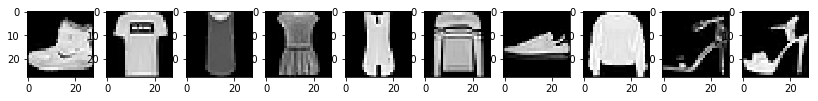

('Image Lables', array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5]))


In [37]:
import matplotlib.pyplot as plt
import numpy as np

f, axarr = plt.subplots(1,10, figsize=(14, 14))
for i in range(0,10):
    axarr[i].imshow(trainX[i],cmap='gray')
plt.show()
print("Image Lables", np.where(trainY[:10] == 1)[1])

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [62]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Dense(28, activation='relu', input_shape=(28,28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
             optimizer='sgd',
             metrics=['accuracy'])

model.summary()


Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_21 (Dense)             (None, 28, 28)            812       
_________________________________________________________________
flatten_2 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_22 (Dense)             (None, 10)                7850      
Total params: 8,662
Trainable params: 8,662
Non-trainable params: 0
_________________________________________________________________


### Execute the model using model.fit()

In [63]:
model.fit(trainX, trainY, batch_size=64, epochs=10)

Epoch 1/10
60000/60000 [==============================] - 3s 42us/sample - loss: 3.4028 - acc: 0.6026
Epoch 2/10
60000/60000 [==============================] - 2s 37us/sample - loss: 0.9718 - acc: 0.6747
Epoch 3/10
60000/60000 [==============================] - 2s 33us/sample - loss: 1.0152 - acc: 0.6666
Epoch 4/10
60000/60000 [==============================] - 2s 32us/sample - loss: 0.9230 - acc: 0.6858
Epoch 5/10
60000/60000 [==============================] - 2s 33us/sample - loss: 0.8715 - acc: 0.7039
Epoch 6/10
60000/60000 [==============================] - 2s 32us/sample - loss: 0.9484 - acc: 0.6965
Epoch 7/10
60000/60000 [==============================] - 2s 32us/sample - loss: 0.9813 - acc: 0.6650
Epoch 8/10
60000/60000 [==============================] - 2s 33us/sample - loss: 1.0182 - acc: 0.6516
Epoch 9/10
60000/60000 [==============================] - 2s 32us/sample - loss: 0.9259 - acc: 0.6878
Epoch 10/10
60000/60000 [==============================] - 2s 33us/sample - loss: 

In [66]:
ret = model.evaluate(testX,testY)
print(model.metrics_names)
print(ret)

10000/10000 [==============================] - 0s 33us/sample - loss: 1.1045 - acc: 0.6748
['loss', 'acc']
[1.1045353338241577, 0.6748]


### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [69]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Dense(28, activation='relu', input_shape=(28,28)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
             optimizer='sgd',
             metrics=['accuracy'])

model.summary()

Model: "sequential_16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_25 (Dense)             (None, 28, 28)            812       
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28)            112       
_________________________________________________________________
flatten_3 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_26 (Dense)             (None, 10)                7850      
Total params: 8,774
Trainable params: 8,718
Non-trainable params: 56
_________________________________________________________________


### Execute the model

In [71]:
model.fit(trainX, trainY, batch_size=64, epochs=10)

Epoch 1/10
60000/60000 [==============================] - 4s 63us/sample - loss: 0.6191 - acc: 0.7842
Epoch 2/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.4643 - acc: 0.8367
Epoch 3/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.4282 - acc: 0.8488
Epoch 4/10
60000/60000 [==============================] - 4s 61us/sample - loss: 0.4079 - acc: 0.8567
Epoch 5/10
60000/60000 [==============================] - 4s 62us/sample - loss: 0.3920 - acc: 0.8626
Epoch 6/10
60000/60000 [==============================] - 4s 61us/sample - loss: 0.3801 - acc: 0.8667
Epoch 7/10
60000/60000 [==============================] - 4s 63us/sample - loss: 0.3701 - acc: 0.8708
Epoch 8/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.3630 - acc: 0.8715
Epoch 9/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.3549 - acc: 0.8756
Epoch 10/10
60000/60000 [==============================] - 4s 61us/sample - loss: 

In [72]:
ret = model.evaluate(testX,testY)
print(model.metrics_names)
print(ret)

10000/10000 [==============================] - 0s 43us/sample - loss: 0.3883 - acc: 0.8626
['loss', 'acc']
[0.3883022943496704, 0.8626]


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [74]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Dense(28, activation='relu', input_shape=(28,28)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation='softmax'))

sgd = tf.keras.optimizers.SGD(lr=0.01)
model.compile(loss='categorical_crossentropy',
             optimizer=sgd,
             metrics=['accuracy'])

model.summary()

Model: "sequential_18"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_29 (Dense)             (None, 28, 28)            812       
_________________________________________________________________
batch_normalization_2 (Batch (None, 28, 28)            112       
_________________________________________________________________
flatten_5 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_30 (Dense)             (None, 10)                7850      
Total params: 8,774
Trainable params: 8,718
Non-trainable params: 56
_________________________________________________________________


In [75]:
model.fit(trainX, trainY, batch_size=64, epochs=10)
ret = model.evaluate(testX,testY)
print(model.metrics_names)
print(ret)

Epoch 1/10
60000/60000 [==============================] - 4s 64us/sample - loss: 0.6278 - acc: 0.7818
Epoch 2/10
60000/60000 [==============================] - 4s 61us/sample - loss: 0.4499 - acc: 0.8419
Epoch 3/10
60000/60000 [==============================] - 4s 62us/sample - loss: 0.4147 - acc: 0.8529
Epoch 4/10
60000/60000 [==============================] - 4s 62us/sample - loss: 0.3944 - acc: 0.8610
Epoch 5/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.3793 - acc: 0.8659
Epoch 6/10
60000/60000 [==============================] - 4s 62us/sample - loss: 0.3680 - acc: 0.8690
Epoch 7/10
60000/60000 [==============================] - 4s 61us/sample - loss: 0.3587 - acc: 0.8730
Epoch 8/10
60000/60000 [==============================] - 4s 59us/sample - loss: 0.3510 - acc: 0.8746
Epoch 9/10
60000/60000 [==============================] - 4s 63us/sample - loss: 0.3448 - acc: 0.8771
Epoch 10/10
10000/10000 [==============================] - 1s 50us/sample - loss: 

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [0]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Dense(100, activation='sigmoid', input_shape=(28,28)))
model.add(tf.keras.layers.Dense(100, activation='sigmoid', input_shape=(28,28)))
model.add(tf.keras.layers.Dense(10, activation='sigmoid', input_shape=(28,28)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation='softmax'))

sgd = tf.keras.optimizers.SGD(lr=0.03)
model.compile(loss='categorical_crossentropy',
             optimizer=sgd,
             metrics=['accuracy'])


## Review model

In [81]:
model.summary()

Model: "sequential_21"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_39 (Dense)             (None, 28, 100)           2900      
_________________________________________________________________
dense_40 (Dense)             (None, 28, 100)           10100     
_________________________________________________________________
dense_41 (Dense)             (None, 28, 10)            1010      
_________________________________________________________________
batch_normalization_5 (Batch (None, 28, 10)            40        
_________________________________________________________________
flatten_7 (Flatten)          (None, 280)               0         
_________________________________________________________________
dense_42 (Dense)             (None, 10)                2810      
Total params: 16,860
Trainable params: 16,840
Non-trainable params: 20
________________________________________________

### Run the model

In [82]:
model.fit(trainX, trainY, batch_size=64, epochs=10)
ret = model.evaluate(testX,testY)
print(model.metrics_names)
print(ret)

Epoch 1/10
60000/60000 [==============================] - 8s 141us/sample - loss: 0.5620 - acc: 0.8011
Epoch 2/10
60000/60000 [==============================] - 8s 136us/sample - loss: 0.4344 - acc: 0.8422
Epoch 3/10
60000/60000 [==============================] - 8s 136us/sample - loss: 0.4098 - acc: 0.8515
Epoch 4/10
60000/60000 [==============================] - 8s 137us/sample - loss: 0.3950 - acc: 0.8555
Epoch 5/10
60000/60000 [==============================] - 8s 137us/sample - loss: 0.3829 - acc: 0.8605
Epoch 6/10
60000/60000 [==============================] - 8s 138us/sample - loss: 0.3676 - acc: 0.8651
Epoch 7/10
60000/60000 [==============================] - 8s 138us/sample - loss: 0.3599 - acc: 0.8673
Epoch 8/10
60000/60000 [==============================] - 8s 137us/sample - loss: 0.3526 - acc: 0.8717
Epoch 9/10
60000/60000 [==============================] - 9s 143us/sample - loss: 0.3470 - acc: 0.8744
Epoch 10/10
10000/10000 [==============================] - 1s 99us/sample